# Olympics 2028 Medal Predictor

**Goal**: Predict gold, silver, and bronze medal counts per country for the 2028 Los Angeles Olympics, with specific attention to home field advantage and economic factors.

**Structure of this notebook**:
1. Data loading & exploration
2. Feature engineering
3. Model training & comparison
4. Validation & evaluation
5. 2028 predictions

---
## 1. Data Loading & Exploration

### What I'm doing
Loading the two main datasets: historical Olympic medal data from Kaggle, and GDP/economic data from the World Bank. Before any modelling, I want to understand the shape and quality of the data — missing values, distributions, and obvious patterns.

### Data sources
- `athlete_events.csv` — 120 years of Olympic athlete results from Kaggle
- `world_bank_gdp.csv` — GDP per capita by country and year from World Bank

### Notes

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
athletes = pd.read_csv('../data/raw/athlete_events.csv')
gdp = pd.read_csv('../data/raw/world_bank_gdp.csv', skiprows=4)

print('Athletes dataset:', athletes.shape)
print('GDP dataset:', gdp.shape)
gdp.head()

Athletes dataset: (271116, 15)
GDP dataset: (266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [3]:
# Aggregate medals per country per year
# Explanation: each row is an athlete-event, so we need to count medals at country level
medals = (
    athletes[athletes['Medal'].notna()]
    .groupby(['Year', 'NOC', 'Medal'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
medals.columns.name = None
medals = medals.rename(columns={'Gold': 'gold', 'Silver': 'silver', 'Bronze': 'bronze'})
medals['total'] = medals['gold'] + medals['silver'] + medals['bronze']

print(medals.shape)
medals.head(10)

(1442, 6)


,Year,NOC,bronze,gold,silver,total
0,1896,AUS,1,2,0,3
1,1896,AUT,2,2,1,5
2,1896,DEN,3,1,2,6
3,1896,FRA,2,5,4,11
4,1896,GBR,3,3,3,9
5,1896,GER,2,25,5,32
6,1896,GRE,20,10,18,48
7,1896,HUN,3,2,1,6
8,1896,SUI,0,1,2,3
9,1896,USA,2,11,7,20


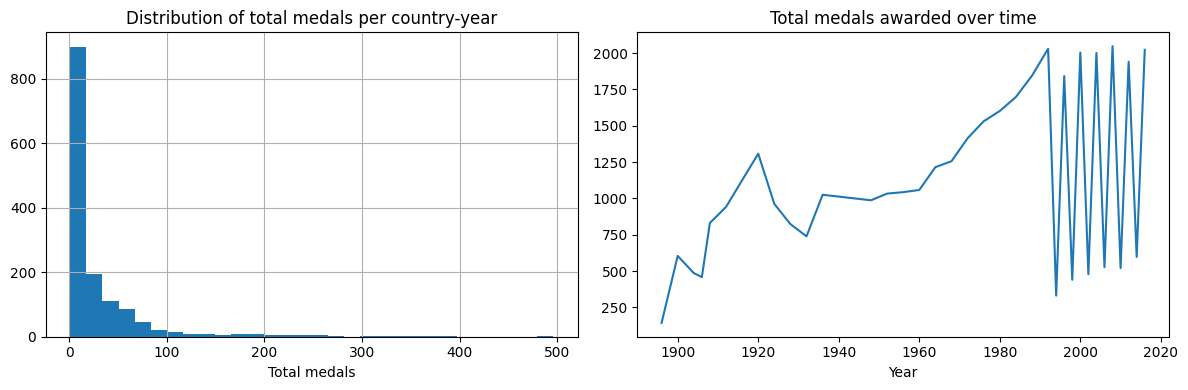

In [4]:
# Quick EDA: distribution of total medals per country
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

medals['total'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution of total medals per country-year')
axes[0].set_xlabel('Total medals')

medals.groupby('Year')['total'].sum().plot(ax=axes[1])
axes[1].set_title('Total medals awarded over time')

plt.tight_layout()
plt.savefig('../data/processed/eda_medals_distribution.png', dpi=150)
plt.show()

# NOTE: Save charts — you'll use them in the README and portfolio

#### EDA observations
- uneven distribution
- historical events have big effects

### Observations
- Distribution is heavily skewed — most countries win very few medals per Olympics
- Each bar represents a country-year combination, not a unique country
- Large countries (USA, Russia, GBR) appear ~30 times and dominate the right tail
- Spikes and drops in total medals over time reflect historical events:
  boycotts (1980, 1984), addition of new sports, and the collapse of the USSR in 1991
- Predictions for smaller countries will be less reliable due to limited historical data

---
## 2. Feature Engineering

### What I'm doing
Building the features that the model will use to make predictions. This is the most important step — a model is only as good as the signals you feed it.

### Key features and the reasoning behind each

| Feature | Rationale |
|---|---|
| `is_host` | Host nations historically win more medals — the home crowd effect |
| `home_boost_multiplier` | Not all nations benefit equally from hosting — this captures how much *this* country has historically benefited |
| `rolling_3game_avg` | Recent form matters more than distant history |
| `gdp_per_capita` | Wealthier countries invest more in sport infrastructure |
| `trend_slope` | Is this country improving or declining over recent games? |

### Notes
*[Log decisions here — e.g. 'Tried using total GDP but per capita was a better predictor. Countries like China have high GDP but performance is more correlated with wealth distribution.']*

In [ ]:
# Host nations — manually defined from historical records
HOST_NATIONS = {
    1896: 'GRE', 1900: 'FRA', 1904: 'USA', 1908: 'GBR', 1912: 'SWE',
    1920: 'BEL', 1924: 'FRA', 1928: 'NED', 1932: 'USA', 1936: 'GER',
    1948: 'GBR', 1952: 'FIN', 1956: 'AUS', 1960: 'ITA', 1964: 'JPN',
    1968: 'MEX', 1972: 'GER', 1976: 'CAN', 1980: 'URS', 1984: 'USA',
    1988: 'KOR', 1992: 'ESP', 1996: 'USA', 2000: 'AUS', 2004: 'GRE',
    2008: 'CHN', 2012: 'GBR', 2016: 'BRA', 2020: 'JPN', 2024: 'FRA',
    2028: 'USA'  # LA 2028
}

medals['is_host'] = medals.apply(
    lambda row: 1 if HOST_NATIONS.get(row['Year']) == row['NOC'] else 0, axis=1
)

print('Host nation rows:', medals['is_host'].sum())
medals[medals['is_host'] == 1][['Year', 'NOC', 'gold', 'total']].head(10)

In [ ]:
# Rolling 3-game medal average per country
# Sort first — rolling requires chronological order
medals = medals.sort_values(['NOC', 'Year'])

medals['rolling_3game_avg'] = (
    medals.groupby('NOC')['total']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Why shift(1)? We use past performance only — never the current game's result.
# This prevents data leakage.
medals[['Year', 'NOC', 'total', 'rolling_3game_avg']].head(15)

In [ ]:
# TODO: Merge GDP data
# Hint: You'll need to standardise country codes first
# World Bank uses ISO-3 (e.g. 'USA'), Kaggle uses NOC codes (e.g. 'USA')
# Some will match, some won't — build a mapping dict for the mismatches

# NOC_TO_ISO = {
#     'GER': 'DEU',
#     'GBR': 'GBR',
#     'CHN': 'CHN',
#     # ... add as you discover mismatches
# }

print('TODO: merge GDP — see NOTES.md for country mapping progress')

---
## 3. Model Training

### What I'm doing
Training two models and comparing them: a Poisson regression baseline (mathematically suited to count data like medal totals) and an XGBoost model which can capture non-linear interactions.

### Why two models?
Poisson regression is interpretable — I can read the coefficients and explain directly what impact each feature has. XGBoost usually predicts more accurately but is harder to explain. Together they give me both accuracy and interpretability.

### Notes
*[Log results here as you train — e.g. 'XGBoost with default params overfit badly. Reduced max_depth to 4, improved validation MAE from 3.2 to 2.1.']*

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import PoissonRegressor
from xgboost import XGBRegressor
import shap

# Features to use in the model
FEATURES = ['rolling_3game_avg', 'is_host', 'gdp_per_capita', 'trend_slope']
TARGET = 'total'

# TODO: Replace with your actual processed dataframe
# df = medals.dropna(subset=FEATURES + [TARGET])
# X = df[FEATURES]
# y = df[TARGET]

print('TODO: fill in once feature engineering is complete')

In [ ]:
# Poisson baseline
# poisson = PoissonRegressor(max_iter=1000)
# poisson.fit(X_train, y_train)

# XGBoost
# xgb = XGBRegressor(
#     n_estimators=200,
#     max_depth=4,          # Kept shallow to reduce overfitting
#     learning_rate=0.05,
#     subsample=0.8,
#     random_state=42
# )
# xgb.fit(X_train, y_train)

# Why these hyperparameters? Log your reasoning here.
print('TODO: train models — see NOTES.md for tuning log')

In [ ]:
# SHAP feature importance
# Shows WHICH features drive predictions and by how much
# This is gold for a portfolio — employers love seeing you explain your model

# explainer = shap.Explainer(xgb)
# shap_values = explainer(X_test)
# shap.summary_plot(shap_values, X_test)
# plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')

print('TODO: run SHAP after model is trained')

---
## 4. Validation

### What I'm doing
Testing how well the model would have predicted Tokyo 2020 if I had trained it on all prior data (1984–2016). This is called a *backtest* and it's the only honest way to evaluate an Olympic prediction model — you cannot use random splits because time matters.

### Why not random cross-validation?
If I randomly split 1984–2024 data, the model could see 2016 data while predicting 1992. That would be *data leakage* — the model is cheating by seeing the future. Time-series splits prevent this.

### Notes
*[Log your backtest results here — which countries did the model get wrong? Why?]*

In [ ]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

# Time-series backtest: train on ≤2016, test on 2020
# train_mask = df['Year'] <= 2016
# test_mask  = df['Year'] == 2020

# X_train, y_train = X[train_mask], y[train_mask]
# X_test,  y_test  = X[test_mask],  y[test_mask]

# Evaluation metrics
# preds = xgb.predict(X_test)
# mae = mean_absolute_error(y_test, preds)
# spearman, _ = spearmanr(y_test, preds)

# print(f'MAE:               {mae:.2f} medals per country')
# print(f'Spearman rank:     {spearman:.3f}  (1.0 = perfect rank order)')

print('TODO: run backtest')

---
## 5. 2028 LA Predictions

### What I'm doing
Generating predictions for the 2028 Los Angeles Olympics. The USA gets `is_host = 1` and the home boost multiplier applied. All other countries get `is_host = 0`.

### Caveats
These are statistical predictions based on historical patterns. They do not account for unexpected events (injuries, geopolitical boycotts, new sports being added). Treat them as a data-informed estimate, not a forecast.

### Notes
*[Write your headline findings here — e.g. 'Model predicts USA gains ~18 extra medals from home advantage. China and Great Britain follow. Notable underperformers vs expectation: ...']*

In [ ]:
# Build 2028 prediction input
# For each country: use 2024 Paris as last game, set is_host = 1 for USA only

# predictions_2028 = df_2024.copy()
# predictions_2028['Year'] = 2028
# predictions_2028['is_host'] = predictions_2028['NOC'].apply(lambda x: 1 if x == 'USA' else 0)

# predictions_2028['predicted_total'] = xgb.predict(predictions_2028[FEATURES])
# predictions_2028 = predictions_2028.sort_values('predicted_total', ascending=False)

# predictions_2028[['NOC', 'predicted_total']].head(20)

print('TODO: generate predictions after model is validated')

In [ ]:
# Visualise top 20 predicted countries
# fig, ax = plt.subplots(figsize=(10, 8))
# top20 = predictions_2028.head(20)
# ax.barh(top20['NOC'][::-1], top20['predicted_total'][::-1])
# ax.set_xlabel('Predicted total medals')
# ax.set_title('Predicted medal counts — 2028 Los Angeles Olympics')
# plt.tight_layout()
# plt.savefig('../data/processed/predictions_2028.png', dpi=150)
# plt.show()

print('TODO: visualise after predictions are ready')

---
## Conclusions

*Write this section last, after all results are in.*

### What I found
- *(headline result 1)*
- *(headline result 2)*
- *(headline result 3)*

### What surprised me
- *(something unexpected from the data or model)*

### What I would do differently
- *(honest reflection — employers respect self-awareness)*

### Potential improvements
- Include sport-specific predictions (athletics, swimming, gymnastics separately)
- Add political/geopolitical features (boycotts, sanctions)
- Use a Bayesian model for uncertainty intervals on each prediction